# Study 14 — What happens when we search for form anywhere?

Study 13 asked whether observed results could distinguish a genuine ability change from ordinary random variation.

But it gave the analysis one major advantage:

> **We told it exactly where to look.**

The possible change point was specified in advance, and the detector examined the 250 frames immediately afterwards.

Real analysis is often much less controlled.

We may inspect a player's whole career, notice a period of unusually strong results, and only then ask whether that period represents genuine form.

That changes the question.

A strong run found at a pre-specified point has one interpretation. The strongest run selected after searching thousands of frames has another.

In this study, the player's underlying ability will **never change**.

The true frame-win probability will remain at **58% throughout the entire career**.

There will be:

- no genuine improvement or decline;
- no temporary form;
- no momentum;
- no opponent effects;
- no parameter uncertainty.

Frames will remain independent, each with the same 58% probability of being won.

We will then slide a fixed **250-frame window** across the career and deliberately search for the strongest-looking period we can find.

The central question is:

> **How strong can the best apparent 250-frame run look when the player's underlying ability never changed at all?**

Study 13 asked:

> **How unusual is this particular run?**

Study 14 asks:

> **How unusual is the best run we were able to find after searching the whole career?**

The aim is to establish a simple but important problem:

> **If we search through enough ordinary random variation, we increase our chances of finding something that looks exceptional.**

## Experimental design

We will keep the world deliberately simple.

Each simulated career will contain **5,000 frames**.

Throughout all 5,000 frames:

- true frame-win probability = 58%;
- frames are independent;
- the player's underlying ability never changes.

We will examine performance using the same **250-frame window** used in Study 13.

But instead of examining one pre-specified block of 250 frames, we will calculate the number of wins in **every possible consecutive 250-frame window** across the career.

For a 5,000-frame career, that gives:

$$
5000 - 250 + 1 = 4751
$$

overlapping windows.

For each career, we will then deliberately select the window containing the **largest number of wins**.

This means the analysis is no longer asking whether one particular run looks unusual.

It is actively searching through thousands of candidate runs and keeping the most impressive one.

The first experiment will therefore have two stages:

1. simulate one completely unchanged 58% career;
2. search that career for its strongest 250-frame window.

We can then compare the strongest run we find with the Study 13 benchmark.

In Study 13, observing **153 or more wins from a pre-specified 250-frame window** had a false-alarm probability of about **16.8%** under a genuine 58% player.

The question now is:

> **What happens to that apparent rarity when we have 4,751 opportunities to find a strong-looking window and deliberately report the best one?**

For now, the window length stays fixed at 250 frames.

We are changing only one thing:

> **where Study 13 specified the place to look in advance, Study 14 searches for the most favourable place afterwards.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Keep the experiment reproducible while still generating a realistic random career.
rng = np.random.default_rng(14)

true_p = 0.58
career_length = 5_000
window_size = 250

# A win is stored as 1 and a loss as 0.
# The player's true ability remains fixed at 58% for the entire career.
career = rng.binomial(1, true_p, size=career_length)

career[:20], career.sum(), career.mean()

(array([0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1]),
 np.int64(2869),
 np.float64(0.5738))

## Searching one unchanged career

We now have one 5,000-frame career generated from a player whose true frame-win probability remained fixed at 58% throughout.

Nothing happened to the player's ability.

The next step is to ignore that privileged knowledge and analyse the results as though we were looking for form.

We will move a 250-frame window across the career one frame at a time.

For each possible starting position, we will count the number of wins in the following 250 frames.

That produces 4,751 overlapping observations of recent performance.

We will then ask:

> **Which 250-frame period looks strongest?**

Importantly, we are not testing a period chosen in advance.

We are allowing the data to show us thousands of possible periods and then deliberately choosing the most impressive one afterwards.

In [2]:
# Use cumulative wins so every 250-frame total can be calculated efficiently.
# Each value represents the wins in one consecutive 250-frame section of the career.
cumulative_wins = np.concatenate(([0], np.cumsum(career)))
rolling_wins = cumulative_wins[window_size:] - cumulative_wins[:-window_size]

best_window_index = np.argmax(rolling_wins)
best_window_wins = rolling_wins[best_window_index]

best_window_start = best_window_index + 1
best_window_end = best_window_start + window_size - 1
best_window_rate = best_window_wins / window_size

len(rolling_wins), best_window_start, best_window_end, best_window_wins, best_window_rate

(4751, np.int64(3788), np.int64(4037), np.int64(163), np.float64(0.652))

## The strongest-looking run

The search found its strongest 250-frame period between frames **3,788 and 4,037**.

During that period, the player won:

$$
163 \text{ of } 250
$$

frames, giving an observed win rate of:

$$
\frac{163}{250} = 65.2\%
$$

That looks substantially stronger than the player's true 58% ability.

It also comfortably exceeds the **153-win threshold** used in Study 13 to signal apparent improvement.

But in this experiment we know something the analyst would not normally know:

> **The player's underlying ability never changed.**

The 65.2% run is entirely the product of ordinary random variation combined with our decision to search the whole career for the most favourable period.

If a 163-win total had been observed in one 250-frame window specified in advance, it would look quite unusual for a genuine 58% player.

But that is not how this run was obtained.

We examined **4,751 possible windows** and selected the strongest one afterwards.

That distinction is now the centre of the study.

## Where does the apparent form appear?

The 163-win period was not chosen because we had any prior reason to inspect frames 3,788–4,037.

It emerged only after scanning the full career.

A rolling plot lets us see the complete search rather than just its winning result.

Each point will represent the number of wins in one 250-frame window.

The horizontal axis therefore shows the **starting frame of the window**, not an individual frame result.

We will also mark:

- the **153-win threshold** used in Study 13;
- the strongest 250-frame window found in this career.

This lets us see how often an unchanged player's rolling performance approaches or exceeds what previously looked like evidence of improvement.

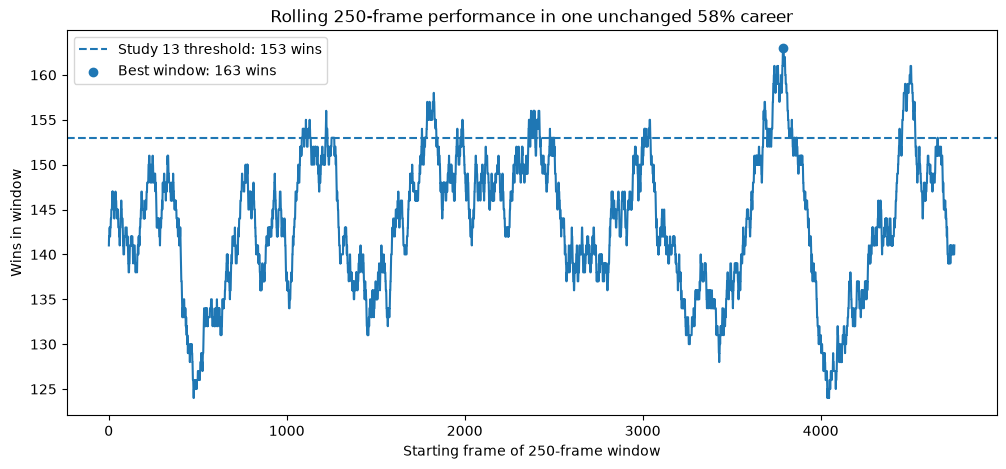

In [3]:
# Plot every possible 250-frame window rather than showing only the one
# selected as the strongest after the search.
window_starts = np.arange(1, len(rolling_wins) + 1)

plt.figure(figsize=(12, 5))
plt.plot(window_starts, rolling_wins)

# Study 13 treated 153 wins as sufficient to signal apparent improvement
# when the observation window had been specified in advance.
plt.axhline(153, linestyle="--", label="Study 13 threshold: 153 wins")

# Highlight the strongest-looking period found by searching this career.
plt.scatter(best_window_start, best_window_wins, zorder=3, label=f"Best window: {best_window_wins} wins")

plt.xlabel("Starting frame of 250-frame window")
plt.ylabel("Wins in window")
plt.title("Rolling 250-frame performance in one unchanged 58% career")
plt.legend()
plt.show()

## What the rolling search reveals

The Study 13 threshold is exceeded in several different parts of this completely unchanged career.

If we had inspected only one of those periods after noticing it, it could easily have looked like evidence that the player had improved.

But the full plot shows what actually happened:

> **We searched a long sequence of ordinary random results until unusually strong-looking periods appeared.**

There is another important feature of the chart.

Neighbouring 250-frame windows overlap heavily.

For example, two adjacent windows share 249 of their 250 frames. Moving the window forward by one position removes only one old result and adds one new result.

That is why the rolling totals form long, smooth-looking rises and falls rather than 4,751 unrelated observations.

Therefore:

> **The 4,751 candidate windows should not be treated as 4,751 independent chances to produce a false alarm.**

The windows are strongly dependent on one another.

For this study, however, we do not need to pretend they are independent.

We can measure the searching effect directly by repeatedly simulating complete unchanged careers and recording only the strongest 250-frame run found in each one.

In [4]:
# Count how many rolling windows meet the Study 13 threshold.
# Because neighbouring windows overlap heavily, also count contiguous
# above-threshold regions rather than treating every window as a separate event.
above_threshold = rolling_wins >= 153
n_above_threshold = above_threshold.sum()

starts_of_regions = np.flatnonzero(
    above_threshold & np.concatenate(([True], ~above_threshold[:-1]))
)

n_regions = len(starts_of_regions)

n_above_threshold, n_regions

(np.int64(527), 36)

## How often did this career look improved?

Across the 4,751 possible 250-frame windows, **527** reached or exceeded the Study 13 threshold of 153 wins.

That is about **11% of all the windows we inspected**.

Those above-threshold windows occurred in **36 contiguous regions** of the rolling series.

The region count should not be interpreted as 36 independent hot streaks. Because neighbouring windows overlap almost completely, a rolling total can move just above and below the threshold several times during one broader period of unusually strong observed results.

The important point is simpler:

> **Once we searched the whole career, evidence that would have triggered the Study 13 detector was no longer difficult to find.**

But one simulated career cannot tell us how typical this is.

Perhaps this particular career happened to contain an unusually extreme run.

To answer that, we need to repeat the experiment across many completely unchanged careers and, for each one, keep only the strongest 250-frame window that the search can find.

In [5]:
# Repeat the whole-career search many times.
# We store only the strongest 250-frame result from each career because
# the quantity of interest is the best apparent run found after searching.
n_careers = 10_000
search_rng = np.random.default_rng(1401)

best_wins_by_career = np.empty(n_careers, dtype=int)

for i in range(n_careers):
    simulated_career = search_rng.binomial(1, true_p, size=career_length)

    cumulative_wins = np.concatenate(([0], np.cumsum(simulated_career)))
    rolling_wins_i = (
        cumulative_wins[window_size:]
        - cumulative_wins[:-window_size]
    )

    best_wins_by_career[i] = rolling_wins_i.max()

# Compare the searched-career result with the 153-win Study 13 threshold.
(
    best_wins_by_career.min(),
    best_wins_by_career.mean(),
    np.median(best_wins_by_career),
    best_wins_by_career.max(),
    np.mean(best_wins_by_career >= 153),
)

(np.int64(153),
 np.float64(165.0404),
 np.float64(165.0),
 np.int64(182),
 np.float64(1.0))

## Searching transforms the meaning of the threshold

The repeated experiment produces a striking result.

Across 10,000 careers in which the player's true frame-win probability remained fixed at 58% throughout, **every simulated career contained at least one 250-frame window with 153 wins or more**.

The strongest window found in a typical career was much stronger than that.

The median searched maximum was:

$$
165 \text{ wins from } 250
$$

or:

$$
66.0\%
$$

Despite the player's true ability remaining at 58%.

The strongest maximum observed across the 10,000 simulations was 182 wins, equivalent to a 72.8% observed win rate over 250 frames.

This changes the interpretation of the Study 13 threshold completely.

In Study 13, **153 wins or more in one pre-specified 250-frame window** occurred about 16.8% of the time under an unchanged 58% player.

Here, when we searched an entire 5,000-frame career and deliberately selected its strongest 250-frame period, **all 10,000 unchanged careers produced at least one window reaching that same threshold**.

This is not because we are treating the 4,751 overlapping windows as independent tests.

We are not.

The simulation preserves their dependence and simply asks what the complete search actually finds.

The important lesson is:

> **A threshold cannot be interpreted without considering how the observation was selected.**

A result that is moderately unusual at one location chosen in advance can become almost inevitable when we search a long career and report only the strongest-looking period.

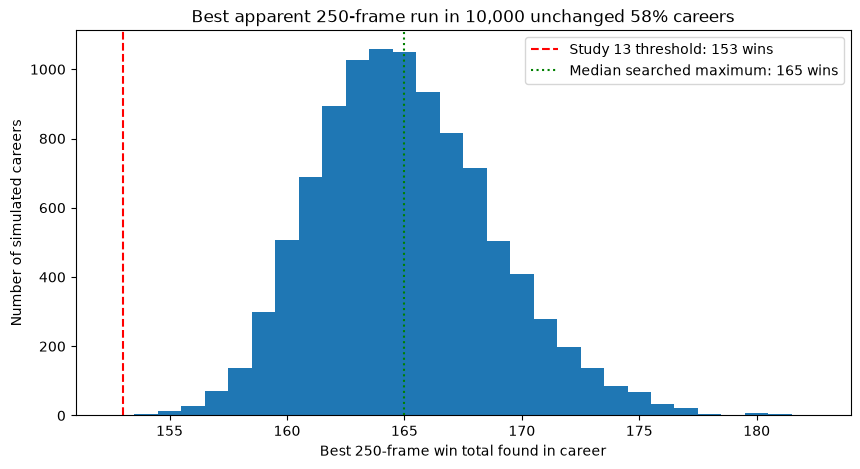

In [6]:
# Show the distribution of the strongest 250-frame run found in each
# completely unchanged career.
plt.figure(figsize=(10, 5))
plt.hist(
    best_wins_by_career,
    bins=np.arange(
        best_wins_by_career.min() - 0.5,
        best_wins_by_career.max() + 1.5,
        1,
    ),
)

# Keep the Study 13 threshold visible so its meaning under a whole-career
# search can be compared directly with the pre-specified-window result.
plt.axvline(
    153,
    linestyle="--",
    color="red",
    label="Study 13 threshold: 153 wins",
)

plt.axvline(
    np.median(best_wins_by_career),
    linestyle=":",
    color="green",
    label=f"Median searched maximum: {np.median(best_wins_by_career):.0f} wins",
)

plt.xlabel("Best 250-frame win total found in career")
plt.ylabel("Number of simulated careers")
plt.title("Best apparent 250-frame run in 10,000 unchanged 58% careers")
plt.legend()
plt.show()

## The distribution of the best run

The histogram makes the selection effect much clearer.

For a 250-frame window chosen in advance, 153 wins looked strong enough in Study 13 to trigger our simple improvement detector.

But after searching an entire 5,000-frame career, 153 wins sits at the extreme left of the distribution of the **best runs found**.

A typical unchanged career produced a strongest window of around **165 wins from 250**, equivalent to an observed win rate of 66%.

That does not mean the player temporarily became a 66% player.

It means that, among thousands of overlapping candidate periods, random variation usually supplied at least one stretch whose observed results looked much stronger than the player's constant 58% ability.

The relevant reference distribution has therefore changed.

If a period was specified before seeing the results, we should compare it with the distribution of one 250-frame sample.

If the period was selected because it was the strongest-looking part of a long career, we should compare it with the distribution of the **strongest period found after that search**.

Those are different questions and they produce very different standards for what counts as unusual.

In [7]:
from scipy.stats import binom

# Compare several win totals under two different selection procedures:
# 1. one 250-frame window specified in advance;
# 2. the strongest 250-frame window found after searching a 5,000-frame career.
thresholds = np.array([153, 160, 165, 170, 175])

pre_specified_prob = binom.sf(thresholds - 1, window_size, true_p)
searched_prob = np.array([
    np.mean(best_wins_by_career >= threshold)
    for threshold in thresholds
])

comparison = list(zip(
    thresholds,
    pre_specified_prob,
    searched_prob,
))

comparison

[(np.int64(153), np.float64(0.16832923537900057), np.float64(1.0)),
 (np.int64(160), np.float64(0.03086712279358694), np.float64(0.9446)),
 (np.int64(165), np.float64(0.005837906930188415), np.float64(0.5268)),
 (np.int64(170), np.float64(0.0007344844597563009), np.float64(0.1249)),
 (np.int64(175), np.float64(6.0065581285446665e-05), np.float64(0.014))]

## The same run can mean something completely different

The comparison shows how dramatically the interpretation changes when the period was selected after searching the data.

| Wins from 250 | Pre-specified window | Best window after career search |
|---:|---:|---:|
| 153 | 16.83% | 100.00% |
| 160 | 3.09% | 94.46% |
| 165 | 0.58% | 52.68% |
| 170 | 0.073% | 12.49% |
| 175 | 0.006% | 1.40% |

Consider **165 wins from 250 frames**.

If those 250 frames had been specified before observing the results, an unchanged 58% player would produce at least 165 wins only about **0.58% of the time**.

That would look highly unusual.

But if we first inspect a 5,000-frame career and then report the strongest 250-frame period we can find, at least 165 wins appears in about **52.7% of unchanged careers**.

The observed run is identical.

What changed is **how we selected it**.

The same point becomes even more striking at 170 wins.

A pre-specified 170-win run occurs only about **0.073%** of the time under the 58% model — roughly 7 times in 10,000 such windows.

Yet after searching a complete 5,000-frame career, about **12.5%** of unchanged players produce a run at least that strong somewhere.

So asking:

> **How unlikely is this run under a 58% player?**

is incomplete.

We also need to ask:

> **Was this the period we intended to examine before seeing the data, or did it attract our attention because it was unusually strong?**

That distinction is the phenomenon usually called the **look-elsewhere effect**.

The terminology is less important than the underlying idea:

> **Searching creates opportunities for randomness to look meaningful.**

## Searching changes the false-alarm threshold

Study 13 used 153 wins from 250 as a deliberately simple decision threshold.

For a single pre-specified window, an unchanged 58% player reaches that threshold about 16.8% of the time.

But Study 14 has shown that the same threshold is far too low once we search an entire career for the strongest-looking period.

We can now examine this systematically.

For each possible threshold, we will compare:

- the probability that one pre-specified 250-frame window reaches it;
- the probability that the **best** 250-frame window found in a 5,000-frame career reaches it.

This lets us ask:

> **What threshold would produce roughly the same false-alarm rate after searching as 153 wins produced before searching?**

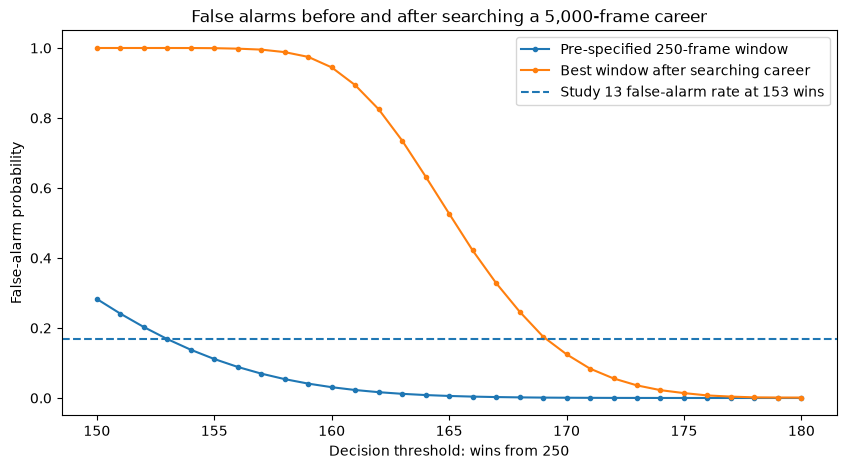

In [8]:
# Compare false-alarm probabilities across a range of possible thresholds.
# The pre-specified probabilities are exact binomial calculations, while
# the searched probabilities come from the 10,000 simulated career searches.
threshold_range = np.arange(150, 181)

pre_specified_false_alarm = binom.sf(
    threshold_range - 1,
    window_size,
    true_p,
)

searched_false_alarm = np.array([
    np.mean(best_wins_by_career >= threshold)
    for threshold in threshold_range
])

plt.figure(figsize=(10, 5))
plt.plot(
    threshold_range,
    pre_specified_false_alarm,
    marker="o",
    markersize=3,
    label="Pre-specified 250-frame window",
)
plt.plot(
    threshold_range,
    searched_false_alarm,
    marker="o",
    markersize=3,
    label="Best window after searching career",
)

plt.axhline(
    0.16832923537900057,
    linestyle="--",
    label="Study 13 false-alarm rate at 153 wins",
)

plt.xlabel("Decision threshold: wins from 250")
plt.ylabel("False-alarm probability")
plt.title("False alarms before and after searching a 5,000-frame career")
plt.legend()
plt.show()

## The threshold has to move

The two curves show that the same numerical threshold has very different false-alarm behaviour depending on whether the observation was chosen in advance or selected after searching.

For a pre-specified 250-frame window, the Study 13 threshold of **153 wins** produces a false-alarm probability of about **16.8%**.

After searching a complete 5,000-frame career for its strongest window, a threshold near 153 is essentially useless: almost every unchanged career reaches it somewhere.

To recover a false-alarm probability similar to Study 13, the threshold has to move much higher — to roughly **169 wins from 250**.

That is an observed win rate of about:

$$
\frac{169}{250} = 67.6\%
$$

for a player whose true underlying frame-win probability is still only 58%.

The search has therefore changed what counts as unusual.

> **Once we select the strongest-looking period after inspecting the whole career, we need substantially stronger evidence before treating that period as exceptional.**

In [9]:
# Find the searched-career threshold whose false-alarm probability is
# closest to Study 13's 16.8% false-alarm rate.
study13_false_alarm = binom.sf(152, window_size, true_p)

closest_index = np.argmin(
    np.abs(searched_false_alarm - study13_false_alarm)
)

matched_threshold = threshold_range[closest_index]
matched_searched_false_alarm = searched_false_alarm[closest_index]

matched_threshold, matched_threshold / window_size, study13_false_alarm, matched_searched_false_alarm

(np.int64(169),
 np.float64(0.676),
 np.float64(0.16832923537900057),
 np.float64(0.1754))

## Matching the Study 13 false-alarm rate

We can now make the threshold comparison more precise.

Study 13 used:

$$
153 \text{ wins from } 250
$$

which corresponds to a 61.2% observed win rate and gives an unchanged 58% player a false-alarm probability of:

$$
16.83\%
$$

For the whole-career search, the closest comparable threshold is:

$$
169 \text{ wins from } 250
$$

or:

$$
67.6\%
$$

Across the 10,000 simulated unchanged careers, at least one window reached 169 wins in about **17.54%** of careers.

The rates do not match exactly because the decision threshold can move only in whole wins, and the searched probability is estimated by simulation.

But the comparison is clear:

> **To obtain roughly the same false-alarm rate after searching the career, the threshold has to rise from 153 wins to about 169 wins.**

That is an increase of **16 wins within the same 250-frame observation window**.

Nothing about the player changed.

Nothing about the window length changed.

The difference comes entirely from the way the period was selected.

This is why evidence discovered by searching cannot automatically be judged by the same standard as evidence specified before looking at the data.

## Conclusion

Study 13 showed that even when we know exactly where a possible ability change might have occurred, ordinary random variation can make unchanged and genuinely changed players produce overlapping evidence.

Study 14 removed that advantage.

The player was deliberately kept completely unchanged:

- true frame-win probability = 58% throughout;
- 5,000 frames per career;
- independent frame results;
- one fixed 250-frame observation window;
- no genuine form or ability change.

The only new ingredient was **searching**.

Instead of examining one 250-frame period specified in advance, we examined every possible 250-frame window and selected the strongest-looking one afterwards.

That was enough to transform the evidence.

In Study 13, an unchanged 58% player produced at least **153 wins from a pre-specified 250-frame window** about **16.8%** of the time.

In Study 14, after searching a 5,000-frame career:

- every one of 10,000 unchanged careers contained at least one 153-win window;
- the median strongest window contained **165 wins from 250**, an observed rate of 66%;
- a 165-win run, which occurs in only about **0.58%** of pre-specified windows, appeared somewhere in about **52.7%** of searched careers;
- a 170-win run, extraordinarily rare at one pre-specified location, still appeared somewhere in about **12.5%** of unchanged careers.

To obtain roughly the same false-alarm rate as the 153-win Study 13 threshold, the searched-career threshold had to rise to about **169 wins from 250**.

The central result is:

> **A strong-looking run cannot be judged only by how unlikely that run would be at one particular location. We must also account for how many opportunities we gave ourselves to find it.**

This is the **look-elsewhere effect**.

It does not require bad analysis, dishonest selection, or an incorrect probability model.

It arises naturally whenever we inspect a large body of noisy data, notice the most interesting part, and then evaluate that part as though it had been chosen in advance.

The progression from Study 13 is therefore:

> **Study 13: a pre-specified run can be ambiguous because results are noisy.**

> **Study 14: searching for the most impressive run makes apparently exceptional evidence much easier to find, even when nothing changed at all.**

Or, more simply:

> **If you search long enough for form, randomness will often give you some.**